In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(123)

# =========================
# 1. Generación de dataset
# =========================
campanas = pd.DataFrame({
    'fecha': pd.date_range('2024-01-01', periods=500, freq='D'),
    'canal': np.random.choice(['Google Ads', 'Facebook', 'Instagram', 'Email', 'TikTok'], 500),
    'campana': np.random.choice(['Verano2024', 'BlackFriday', 'Navidad', 'Descuento10', 'LanzamientoProducto'], 500),
    'impresiones': np.random.randint(1000, 50000, 500),
    'clicks': np.random.randint(50, 5000, 500),
    'conversiones': np.random.randint(5, 500, 500),
    'gasto': np.random.uniform(100, 5000, 500),
    'ingresos': np.random.uniform(500, 15000, 500),
    'segmento': np.random.choice(['18-25', '26-35', '36-45', '46+'], 500)
})

campanas['clicks'] = campanas[['clicks', 'impresiones']].min(axis=1)
campanas['conversiones'] = campanas[['conversiones', 'clicks']].min(axis=1)

campanas





,fecha,canal,campana,impresiones,clicks,conversiones,gasto,ingresos,segmento
0,2024-01-01,Instagram,LanzamientoProducto,6840,4940,221,821.008586,5533.971195,26-35
1,2024-01-02,TikTok,Navidad,29290,3122,274,881.773972,1231.886609,46+
2,2024-01-03,Instagram,BlackFriday,37866,4872,313,4995.427996,5489.177508,18-25
3,2024-01-04,Facebook,Descuento10,12127,2680,71,1945.037842,11838.700604,18-25
4,2024-01-05,Email,BlackFriday,32368,2573,411,2841.354480,1955.792112,26-35
...,...,...,...,...,...,...,...,...,...
495,2025-05-10,TikTok,Descuento10,18070,579,377,3725.280399,9066.292176,36-45
496,2025-05-11,Instagram,LanzamientoProducto,33321,3910,465,4014.285505,9108.936929,26-35
497,2025-05-12,Facebook,Navidad,27166,3976,138,768.597937,7781.194938,46+
498,2025-05-13,Facebook,Navidad,14725,4864,63,2546.229723,11623.633981,36-45


In [2]:
# =========================
# 2. Features de negocio
# =========================
campanas['ctr'] = (campanas['clicks'] / campanas['impresiones']) * 100

campanas['tasa_de_conversion'] = np.where(
    campanas['clicks'] > 0,
    (campanas['conversiones'] / campanas['clicks']) * 100,
    0
)

campanas['ROI'] = (campanas['ingresos'] - campanas['gasto']) / campanas['gasto'] * 100

campanas['CPA'] = np.where(
    campanas['conversiones'] > 0,
    campanas['gasto'] / campanas['conversiones'],
    np.nan
)

campanas['mes'] = campanas['fecha'].dt.to_period('M')

In [3]:
# =========================
# 3. Análisis
# =========================
roi_por_canal = campanas.groupby('canal')['ROI'].mean().sort_values(ascending=False)
conversion_por_campana = campanas.groupby('campana')['tasa_de_conversion'].mean().sort_values(ascending=False)
edad_mas_rentable = campanas.groupby('segmento')['ingresos'].sum().sort_values(ascending=False)

top_combinaciones = campanas.groupby(['canal','campana'])['ROI'].mean().sort_values(ascending=False).head(5)

ingresos_por_mes = campanas.groupby('mes')['ingresos'].sum()

print("=== ROI por canal ===")
print(roi_por_canal)

print("\n=== Conversión por campaña ===")
print(conversion_por_campana)

print("\n=== Segmento más rentable ===")
print(edad_mas_rentable)

print("\n=== Top combinaciones canal-campaña por ROI ===")
print(top_combinaciones)

=== ROI por canal ===
canal
Facebook      650.915481
Instagram     501.030728
TikTok        498.794851
Google Ads    475.530097
Email         345.421231
Name: ROI, dtype: float64

=== Conversión por campaña ===
campana
Verano2024             20.263478
Descuento10            18.021066
BlackFriday            17.518057
LanzamientoProducto    17.416300
Navidad                16.465379
Name: tasa_de_conversion, dtype: float64

=== Segmento más rentable ===
segmento
18-25    1.035631e+06
26-35    1.008297e+06
46+      9.924074e+05
36-45    8.112080e+05
Name: ingresos, dtype: float64

=== Top combinaciones canal-campaña por ROI ===
canal      campana            
Facebook   Navidad                972.464210
           LanzamientoProducto    774.823377
TikTok     Verano2024             750.585134
Facebook   Verano2024             673.642111
Instagram  LanzamientoProducto    624.895483
Name: ROI, dtype: float64


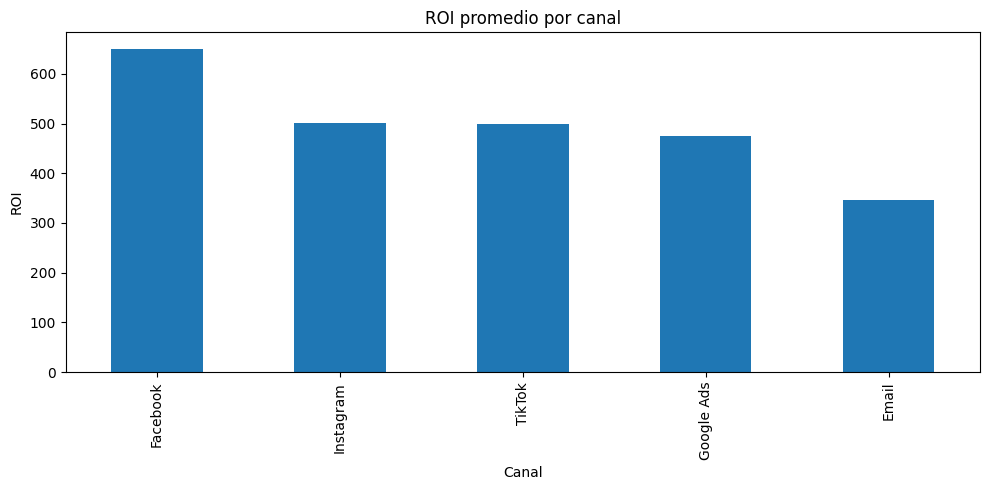

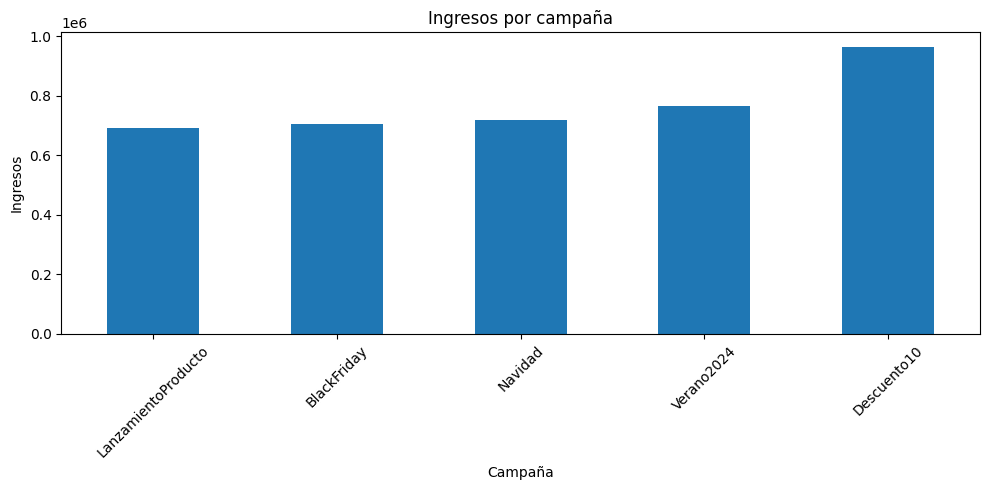

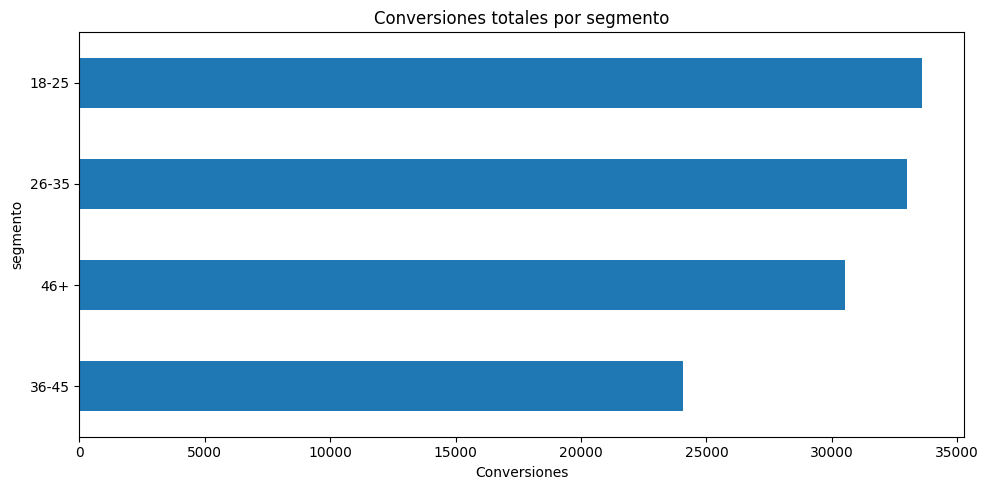

In [4]:
# =========================
# 4. Visualización
# =========================
roi_por_canal.plot(kind='bar', figsize=(10,5))
plt.title('ROI promedio por canal')
plt.ylabel('ROI')
plt.xlabel('Canal')
plt.tight_layout()
plt.show()

campanas.groupby('campana')['ingresos'].sum().sort_values().plot(kind='bar', figsize=(10,5))
plt.title('Ingresos por campaña')
plt.ylabel('Ingresos')
plt.xlabel('Campaña')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

campanas.groupby('segmento')['conversiones'].sum().sort_values().plot(kind='barh', figsize=(10,5))
plt.title('Conversiones totales por segmento')
plt.xlabel('Conversiones')
plt.tight_layout()
plt.show()

In [5]:
# =========================
# 5. Export
# =========================
campanas.to_csv("resultados_marketing.csv", index=False)
